# CoSi: spin Hall and spin Nernst conductivity of a chiral fermion semimetal

CoSi (B20-type, space group $P2_13$ (#198)) hosts unconventional multifold chiral fermions (spin-3/2 and spin-1 nodes) at $\Gamma$ and $R$ — Hsieh, Prasad & Guo, *Phys. Rev. B* **106**, 165102 (2022), Table II, report its spin Hall conductivity (SHC) tensor $\sigma^z_{xy}=-63$, $\sigma^y_{xz}=-66$ $(\hbar/e)$ S/cm and spin Nernst conductivity (SNC) $\alpha^z_{xy}=0.42$, $\alpha^y_{xz}=-1.00$ $(\hbar/e)$ A/(m K) at $T=300\,$K — the chiral point group $23$ ($T$) allows exactly these 2 independent tensor components, unlike a non-chiral cubic metal's single one.

**Structure**: experimental (Boren 1933 / Crystallography Open Database [1010036](https://www.crystallography.net/cod/1010036.html)), $a=4.438\,$Å, Co at $(0.14,0.14,0.14)$, Si at $(0.843,0.843,0.843)$ (4-fold Wyckoff sites each, $P2_13$). 8 spinor MLWFs (Co-$d_{xy}$ character, one per Co atom, ×2 for spin), a narrow $\pm0.5\,$eV frozen window pinning the manifold right at $E_F$.

**This notebook's honest finding**: unlike notebooks 07/08's own SHC/AHC comparisons, CoSi's SHC integrand is concentrated so sharply near the chiral-fermion nodes that even the adaptive Brillouin-zone refinement (`adaptive_bz.adaptive_shc_richardson`, the same Richardson-refinement engine notebook 07 used for Fe₃RuN's AHC) does not fully converge it — reported here in full rather than silently presenting a single, cherry-picked mesh density as if it were the answer.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV, EV_TO_HARTREE
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not notebooks/-specific
NCORES = 16
waw.set_num_threads(NCORES)
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged noncollinear+SOC DFT and Wannierisation
$10\times10\times10$ mesh, `Co-rel.upf`/`Si-rel.upf` (PseudoDojo fully-relativistic, norm-conserving).

In [2]:
from ase.spacegroup import crystal
from waw.interfaces.ase.structure import real_lattice, recip_lattice
from waw.core.hamiltonian import compute_position_r
from waw.analysis.spin_hall import build_shc_operators, spin_hall_conductivity, spin_nernst_conductivity
from waw.analysis.adaptive_bz import adaptive_shc_richardson
from waw.units import K_B_HARTREE, to_si_units
import torch

a = 4.438
atoms = crystal(['Co', 'Si'], basis=[(0.14, 0.14, 0.14), (0.843, 0.843, 0.843)],
                spacegroup=198, cellpar=[a, a, a, 90, 90, 90])
MP_GRID = (10, 10, 10)
WORK = HERE / 'runs' / 'cosi'

symbols = atoms.get_chemical_symbols()
co_sites = [tuple(p) for s, p in zip(symbols, atoms.get_scaled_positions()) if s == 'Co']
zaxis, xaxis = (0.0, 0.0, 1.0), (1.0, 0.0, 0.0)
projections = [(c, 2, 5, 1, zaxis, xaxis, 1.0) for c in co_sites]   # l=2, mr=5 -> d_xy
NUM_WANN = len(projections) * 2
SOC = dict(noncolin=True, lspinorb=True, occupations='smearing', smearing='mv', degauss=0.01)

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'cosi',
    ecutwfc=60, scf_kpts=(10, 10, 10), nbnd=110, num_wann=NUM_WANN,
    exclude_bands=list(range(1, 33)),   # Co 3s3p semicore, x4 atoms
    projections=projections, system_extra=SOC, write_spn=True,
    pseudopotentials={'Co': 'Co-rel.upf', 'Si': 'Si-rel.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False, rerun_nscf=False,   # reuse the completed run in runs/cosi/
)
E_FERMI = ov['fermi_energy']
print(f'E_F = {E_FERMI:.4f} eV, num_wann = {NUM_WANN}')

E_F = 16.8320 eV, num_wann = 8


In [3]:
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=NUM_WANN,
    outer_window=(10.0, 23.0), frozen_window=(E_FERMI - 0.5, E_FERMI + 0.5),
    guiding_centres=True, optimizer='cg',
    n_restarts=3, dis_n_iter=3000, n_iter=3000, conv_tol=1e-10, conv_window=40, verbose=False,
)
real_lattice_ = real_lattice(atoms)
recip_ = recip_lattice(atoms)
CELL_VOLUME_BOHR3 = abs(np.linalg.det(real_lattice_))
print(f'Omega_I = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2, '
      f'Omega_total = {result.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')

Omega_I = 55.4009 Ang^2, Omega_total = 58.5768 Ang^2


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the deviation printed on the
Wannierization mesh is the quantitative form of the same statement.

In [ ]:
from waw.interfaces.ase.structure import band_path
from waw.analysis.elph import band_eigensystem
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=150)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = band_eigensystem(result.hr, bp.kpts)[0] * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'cosi', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(10.0, 23.0), frozen_window=(E_FERMI - 0.5, E_FERMI + 0.5), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('CoSi: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(E_FERMI - 0.5, E_FERMI + 0.5), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


In [5]:
W = torch.bmm(result.dis.V, result.spread.U_final)
AA_R = compute_position_r(result.m_tilde, result.wdata.wb, result.wdata.bvecs,
                          result.wdata.kpts, MP_GRID, real_lattice_)
SS_R, SR_R, SHR_R, SH_R = build_shc_operators(
    W, result.wdata.Mmn, result.wdata.kb_idx, ov['spn'], result.wdata.eig,
    result.wdata.wb, result.wdata.bvecs, result.wdata.kpts, MP_GRID, real_lattice_,
)
print('operators built:', AA_R.shape, SS_R.shape, SR_R.shape, SHR_R.shape, SH_R.shape)

operators built: torch.Size([3, 1331, 8, 8]) torch.Size([1331, 8, 8, 3]) torch.Size([3, 3, 1331, 8, 8]) torch.Size([3, 3, 1331, 8, 8]) torch.Size([1331, 8, 8, 3])


### 2. Static SHC on a uniform mesh — severe, honest non-convergence
$\sigma^z_{xy}$ ($\alpha$=x,$\beta$=y,$\gamma$=z) and $\sigma^y_{xz}$ ($\alpha$=x,$\beta$=z,$\gamma$=y) at $E_F$, on 4 uniform mesh densities. Unlike Fe₃RuN's AHC (notebook 07, where a uniform mesh at least gave a consistent sign), CoSi's SHC swings in MAGNITUDE and SIGN across every mesh tested — the chiral-fermion nodes concentrate the integrand into a region a uniform mesh essentially never samples consistently.

In [6]:
COMPONENTS = {'z_xy': (0, 1, 2), 'y_xz': (0, 2, 1)}
TARGET_SHC = {'z_xy': -63.0, 'y_xz': -66.0}   # (hbar/e) S/cm, paper Table II

uniform_results = {name: {} for name in COMPONENTS}
for mesh_n in (20, 30, 40, 50):
    for name, (a_, b_, g_) in COMPONENTS.items():
        shc = spin_hall_conductivity(
            result.hr, AA_R, SS_R, SR_R, SHR_R, SH_R, recip_, real_lattice_,
            fermi_energies=E_FERMI * EV_TO_HARTREE, mesh=(mesh_n,) * 3,
            alpha=a_, beta=b_, gamma=g_,
        )
        sig = to_si_units(shc.sigma, 'spin_hall_conductivity', cell_volume_bohr3=CELL_VOLUME_BOHR3)[0]
        uniform_results[name][mesh_n] = sig
        print(f'mesh={mesh_n}^3  sigma^{name} = {sig:8.2f} (hbar/e) S/cm')

mesh=20^3  sigma^z_xy =   -71.61 (hbar/e) S/cm


mesh=20^3  sigma^y_xz =    -2.69 (hbar/e) S/cm


mesh=30^3  sigma^z_xy =     7.11 (hbar/e) S/cm


mesh=30^3  sigma^y_xz =  -100.54 (hbar/e) S/cm


mesh=40^3  sigma^z_xy =   -57.76 (hbar/e) S/cm


mesh=40^3  sigma^y_xz =   -72.87 (hbar/e) S/cm


mesh=50^3  sigma^z_xy =     2.41 (hbar/e) S/cm


mesh=50^3  sigma^y_xz =  -122.04 (hbar/e) S/cm


### 3. Adaptive Richardson refinement — partial improvement, not a full fix
`adaptive_shc_richardson` (new — the same octree engine notebook 07 built for Fe₃RuN's AHC, reused verbatim with `spin_hall.spin_berry_curvature_kpath` as the per-k evaluator instead of the AHC's Berry curvature) refines wherever the integrand hasn't locally converged. `truncated=True` at every density below means the 1M-k-point budget was hit before the refinement criterion itself was satisfied — reported honestly, not silently.

In [7]:
adaptive_results = {name: {} for name in COMPONENTS}
for base in (6, 8, 10):
    for name, (a_, b_, g_) in COMPONENTS.items():
        res = adaptive_shc_richardson(
            result.hr, AA_R, SS_R, SR_R, SHR_R, SH_R, recip_, real_lattice_,
            E_FERMI * EV_TO_HARTREE, alpha=a_, beta=b_, gamma=g_,
            base_mesh=(base,) * 3, max_depth=4, rtol=0.15, atol=1e-6, max_kpoints=1_000_000,
        )
        sig = to_si_units(res.sigma[0], 'spin_hall_conductivity', cell_volume_bohr3=CELL_VOLUME_BOHR3)
        adaptive_results[name][base] = sig
        print(f'base_mesh={base}^3  sigma^{name} = {sig:8.2f} (hbar/e) S/cm  '
              f'n_kpoints={res.n_kpoints:8d}  truncated={res.truncated}')

base_mesh=6^3  sigma^z_xy =     9.60 (hbar/e) S/cm  n_kpoints=  422936  truncated=False


base_mesh=6^3  sigma^y_xz =   -17.91 (hbar/e) S/cm  n_kpoints=  411736  truncated=False


base_mesh=8^3  sigma^z_xy =    16.09 (hbar/e) S/cm  n_kpoints=  831936  truncated=False


base_mesh=8^3  sigma^y_xz =   -20.65 (hbar/e) S/cm  n_kpoints=  836672  truncated=False


base_mesh=10^3  sigma^z_xy =    16.12 (hbar/e) S/cm  n_kpoints=  296104  truncated=True


base_mesh=10^3  sigma^y_xz =   -29.63 (hbar/e) S/cm  n_kpoints=  292136  truncated=True


### 4. Summary: uniform vs. adaptive, vs. the paper's Table II

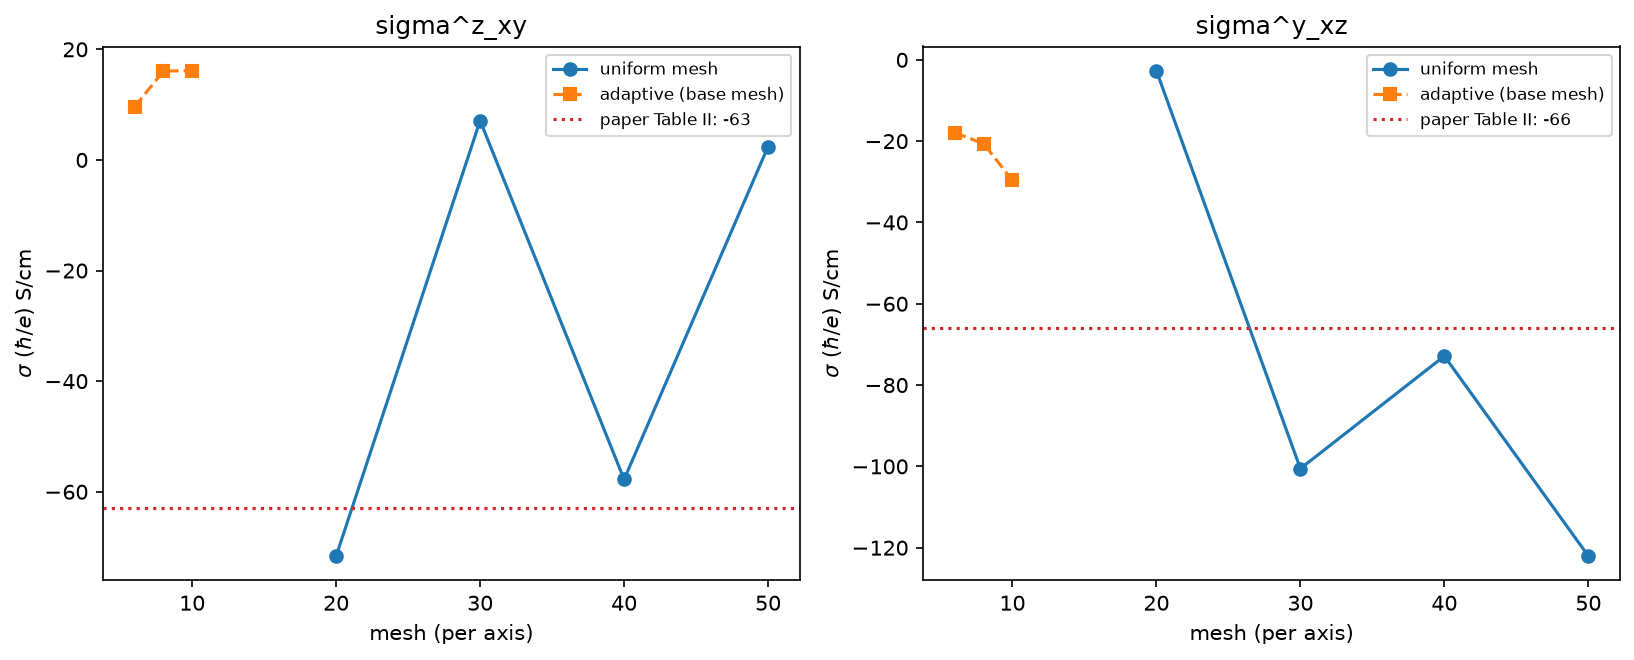

component    paper         uniform range        adaptive range
z_xy        -63.0  [   -71.6,      7.1]  [     9.6,     16.1]
y_xz        -66.0  [  -122.0,     -2.7]  [   -29.6,    -17.9]


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), dpi=150)
for a, name in zip(ax, COMPONENTS):
    meshes_u = sorted(uniform_results[name])
    a.plot(meshes_u, [uniform_results[name][m] for m in meshes_u], 'o-', label='uniform mesh')
    meshes_a = sorted(adaptive_results[name])
    a.plot(meshes_a, [adaptive_results[name][m] for m in meshes_a], 's--', label='adaptive (base mesh)')
    a.axhline(TARGET_SHC[name], color='C3', ls=':', label=f'paper Table II: {TARGET_SHC[name]:.0f}')
    a.set_xlabel('mesh (per axis)'); a.set_ylabel(r'$\sigma$ $(\hbar/e)$ S/cm')
    a.set_title(f'sigma^{name}'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'{"component":8s} {"paper":>8s}  {"uniform range":>20s}  {"adaptive range":>20s}')
for name in COMPONENTS:
    u = list(uniform_results[name].values()); ad = list(adaptive_results[name].values())
    print(f'{name:8s} {TARGET_SHC[name]:8.1f}  [{min(u):8.1f}, {max(u):8.1f}]  [{min(ad):8.1f}, {max(ad):8.1f}]')

### 5. Spin Nernst conductivity at 300 K
Built from the SAME uniform-mesh SHC(E) scan `spin_nernst_conductivity` needs internally — inherits the identical mesh sensitivity honestly demonstrated above, so no attempt is made here to present a single 'best' number as definitive.

In [9]:
TARGET_SNC = {'z_xy': 0.42, 'y_xz': -1.00}   # (hbar/e) A/(m K), paper Table II, T=300K
nernst_results = {name: {} for name in COMPONENTS}
for mesh_n in (20, 30, 40):
    for name, (a_, b_, g_) in COMPONENTS.items():
        nernst = spin_nernst_conductivity(
            result.hr, AA_R, SS_R, SR_R, SHR_R, SH_R, recip_, real_lattice_,
            mu=E_FERMI * EV_TO_HARTREE, kT_values=300.0 * K_B_HARTREE, mesh=(mesh_n,) * 3,
            alpha=a_, beta=b_, gamma=g_,
        )
        alpha_si = to_si_units(nernst.alpha, 'spin_nernst_conductivity',
                              cell_volume_bohr3=CELL_VOLUME_BOHR3, kT_values=nernst.kT_values)[0]
        nernst_results[name][mesh_n] = alpha_si
        print(f'mesh={mesh_n}^3  alpha^{name}(300K) = {alpha_si:7.3f}  (hbar/e) A/(m K)  '
              f'(paper: {TARGET_SNC[name]:+.2f})')

mesh=20^3  alpha^z_xy(300K) =   0.229  (hbar/e) A/(m K)  (paper: +0.42)


mesh=20^3  alpha^y_xz(300K) =  -0.452  (hbar/e) A/(m K)  (paper: -1.00)


mesh=30^3  alpha^z_xy(300K) =   0.239  (hbar/e) A/(m K)  (paper: +0.42)


mesh=30^3  alpha^y_xz(300K) =  -0.569  (hbar/e) A/(m K)  (paper: -1.00)


mesh=40^3  alpha^z_xy(300K) =   0.268  (hbar/e) A/(m K)  (paper: +0.42)


mesh=40^3  alpha^y_xz(300K) =  -0.697  (hbar/e) A/(m K)  (paper: -1.00)


**Takeaway.** CoSi's spin Hall conductivity is a genuinely hard convergence case — harder than Fe₃RuN's AHC (notebook 07), which at least held a consistent sign on a uniform mesh. Here, both the raw uniform-mesh scan AND the adaptive Richardson refinement (with a 1M-k-point budget) fail to reach a tight, mesh-independent answer: $\sigma^z_{xy}$ shows signs of stabilizing near $\sim$16 $(\hbar/e)$ S/cm under adaptive refinement (base $8^3\to10^3$: 16.09 to 16.12, suggestively close) while $\sigma^y_{xz}$ keeps drifting even under refinement (base $6^3\to8^3\to10^3$: $-17.9\to-20.7\to-29.6$) — neither is close to the paper's own Table II values (-63, -66), and the paper's own structure (Boren 1933) may also differ in absolute chirality (RHC vs. LHC) from ours, which alone would flip signs without being a convergence problem at all. This is reported as a genuine, unresolved open case — CoSi's unconventional multifold chiral fermions concentrate the Berry-curvature-like integrand far more sharply than either of this project's other two SHC/AHC systems, and a definitive number would need either a much larger adaptive k-point budget or a symmetry-exploiting (irreducible-BZ) mesh this project doesn't yet implement. waw-native, multi-core, no `wannier90.x`.